# Postgres CPU Time Comparison
## TPC-H SF20 — OS-level CPU vs EXPLAIN ANALYZE vs Firebolt

**Research question:** How does Postgres CPU time compare to Firebolt's
engine-reported CPU for the same TPC-H queries?

Data collected by `collect_postgres_cpu.py`:
```bash
python collect_postgres_cpu.py --database tpch20g --rounds 3
```

**CPU measurement approaches:**
- `proc_cpu_ms` — actual OS-level CPU from `/proc/<pid>/stat` (user + system)
- `explain_total_ms` — EXPLAIN ANALYZE Execution Time + Planning Time (wall-clock)
- Firebolt `avg_cpu_time` — engine-reported `cpu_usage_us` from `engine_query_history`

The key insight: `explain_total_ms` includes I/O waits and is *not* pure CPU.
The `/proc` measurement gives actual CPU seconds consumed by the backend process,
which is directly comparable to Firebolt's `cpu_usage_us`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('./metrics_witho/output')
PG_FILE  = DATA_DIR / 'TPCH-tpch20g-sql-metrics-postgres-cpu.json'
FB_FILE  = DATA_DIR / 'TPCH-tpch20g-sql-metrics-firebolt.json'

/home/mikeg/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load Postgres results

In [2]:
with open(PG_FILE) as f:
    pg_raw = json.load(f)

pg = pd.DataFrame(pg_raw)
pg = pg[pg['ok']].copy()

print(f'{len(pg)} successful Postgres executions')
print(f'Queries: {pg["query_idx"].nunique()}')
print(f'Rounds:  {pg["round"].nunique()}')

has_proc = (pg['proc_cpu_ms'] > 0).any()
print(f'/proc CPU data available: {has_proc}')
pg.head()

66 successful Postgres executions
Queries: 22
Rounds:  3
/proc CPU data available: True


,query_idx,query_label,round,proc_cpu_ms,proc_user_ms,proc_sys_ms,explain_exec_ms,explain_plan_ms,explain_total_ms,scanned_bytes,wall_ms,ok
0,0,Q01,0,44740.0,39510.0,5230.0,45077.987,2.394,45080.381,92139945984,45086.641788,True
1,0,Q01,1,57470.0,50820.0,6650.0,59604.149,0.201,59604.350,92139945984,59616.826057,True
2,0,Q01,2,38020.0,34150.0,3870.0,38276.582,0.451,38277.033,92139945984,38277.839422,True
3,1,Q02,0,9380.0,4540.0,4840.0,10392.121,8.354,10400.475,209127555072,10403.680325,True
4,1,Q02,1,8330.0,4560.0,3770.0,8447.168,9.469,8456.637,209041244160,8457.545757,True


In [3]:
# Aggregate per-query means
pg_agg = (
    pg.groupby(['query_idx', 'query_label'])
    .agg(
        proc_cpu_ms_mean     = ('proc_cpu_ms', 'mean'),
        proc_cpu_ms_std      = ('proc_cpu_ms', 'std'),
        explain_total_ms_mean = ('explain_total_ms', 'mean'),
        explain_total_ms_std  = ('explain_total_ms', 'std'),
        explain_exec_ms_mean  = ('explain_exec_ms', 'mean'),
        scanned_bytes_mean   = ('scanned_bytes', 'mean'),
        wall_ms_mean         = ('wall_ms', 'mean'),
        n = ('ok', 'count'),
    )
    .reset_index()
)
pg_agg.head()

,query_idx,query_label,proc_cpu_ms_mean,proc_cpu_ms_std,explain_total_ms_mean,explain_total_ms_std,explain_exec_ms_mean,scanned_bytes_mean,wall_ms_mean,n
0,0,Q01,46743.333333,9878.544090,47653.921333,10894.078437,47652.906000,9.213995e+10,47660.435756,3
1,1,Q02,8663.333333,621.154838,9081.881333,1142.443222,9075.650000,2.090569e+11,9083.636681,3
2,2,Q03,17526.666667,241.729877,19498.803333,820.317119,19496.568667,1.966372e+11,19506.479025,3
3,3,Q04,4653.333333,323.316151,8791.773000,1764.372226,8785.114667,3.078896e+11,8793.333530,3
4,4,Q05,18596.666667,258.134332,22837.430333,986.739387,22830.863000,2.094278e+11,22838.621378,3


## 2. Load Firebolt isolation metrics for comparison

In [4]:
with open(FB_FILE) as f:
    fb_raw = json.load(f)

fb_rows = []
for qi, entry in enumerate(fb_raw):
    fb_rows.append({
        'query_idx': qi,
        'query_label': f'Q{qi+1:02d}',
        'fb_cpu_ms': entry.get('avg_cpu_time', 0),
        'fb_scan_bytes': entry.get('avg_scan_bytes', 0),
        'fb_duration_ms': entry.get('avg_duration', 0) * 1000,  # s → ms
    })

fb = pd.DataFrame(fb_rows)
print(f'{len(fb)} Firebolt queries loaded')
fb.head()

22 Firebolt queries loaded


,query_idx,query_label,fb_cpu_ms,fb_scan_bytes,fb_duration_ms
0,0,Q01,16721.677,6.719698e+09,2284.203768
1,1,Q02,3141.270,7.904234e+08,531.558990
2,2,Q03,17648.200,3.425870e+09,2475.815296
3,3,Q04,8602.612,2.201953e+09,1157.207489
4,4,Q05,17168.772,3.265471e+09,2251.958132


## 3. Merge and compare

In [5]:
merged = pg_agg.merge(fb, on=['query_idx', 'query_label'])

# Determine best Postgres CPU metric
if has_proc:
    merged['pg_cpu_ms'] = merged['proc_cpu_ms_mean']
    pg_cpu_label = '/proc CPU'
else:
    merged['pg_cpu_ms'] = merged['explain_total_ms_mean']
    pg_cpu_label = 'EXPLAIN ANALYZE total'

merged['cpu_ratio_fb_pg'] = merged['fb_cpu_ms'] / merged['pg_cpu_ms'].replace(0, np.nan)
merged['scan_ratio_fb_pg'] = merged['fb_scan_bytes'] / merged['scanned_bytes_mean'].replace(0, np.nan)

display_cols = ['query_label', 'pg_cpu_ms', 'fb_cpu_ms', 'cpu_ratio_fb_pg',
                'scanned_bytes_mean', 'fb_scan_bytes', 'scan_ratio_fb_pg']
display(merged[display_cols].style.format({
    'pg_cpu_ms': '{:.1f}', 'fb_cpu_ms': '{:.1f}', 'cpu_ratio_fb_pg': '{:.2f}',
    'scanned_bytes_mean': '{:.0f}', 'fb_scan_bytes': '{:.0f}', 'scan_ratio_fb_pg': '{:.2f}',
}))

print(f'\nPostgres CPU metric: {pg_cpu_label}')
print(f'Firebolt CPU metric: engine_query_history cpu_usage_us')

,query_label,pg_cpu_ms,fb_cpu_ms,cpu_ratio_fb_pg,scanned_bytes_mean,fb_scan_bytes,scan_ratio_fb_pg
0,Q01,46743.3,16721.7,0.36,92139945984,6719698048,0.07
1,Q02,8663.3,3141.3,0.36,209056866304,790423354,0.00
2,Q03,17526.7,17648.2,1.01,196637245440,3425869921,0.02
3,Q04,4653.3,8602.6,1.85,307889569792,2201952870,0.01
4,Q05,18596.7,17168.8,0.92,209427808256,3265471293,0.02
5,Q06,6793.3,7184.6,1.06,73711681536,3359849024,0.05
6,Q07,12423.3,31319.5,2.52,169397551104,3625450028,0.02
7,Q08,4513.3,8432.9,1.87,171341750272,3879846915,0.02
8,Q09,45933.3,40907.0,0.89,3441838768128,5000396002,0.00
9,Q10,13680.0,13244.0,0.97,236563021824,4506385861,0.02



Postgres CPU metric: /proc CPU
Firebolt CPU metric: engine_query_history cpu_usage_us


## 4. CPU scatter: Postgres vs Firebolt

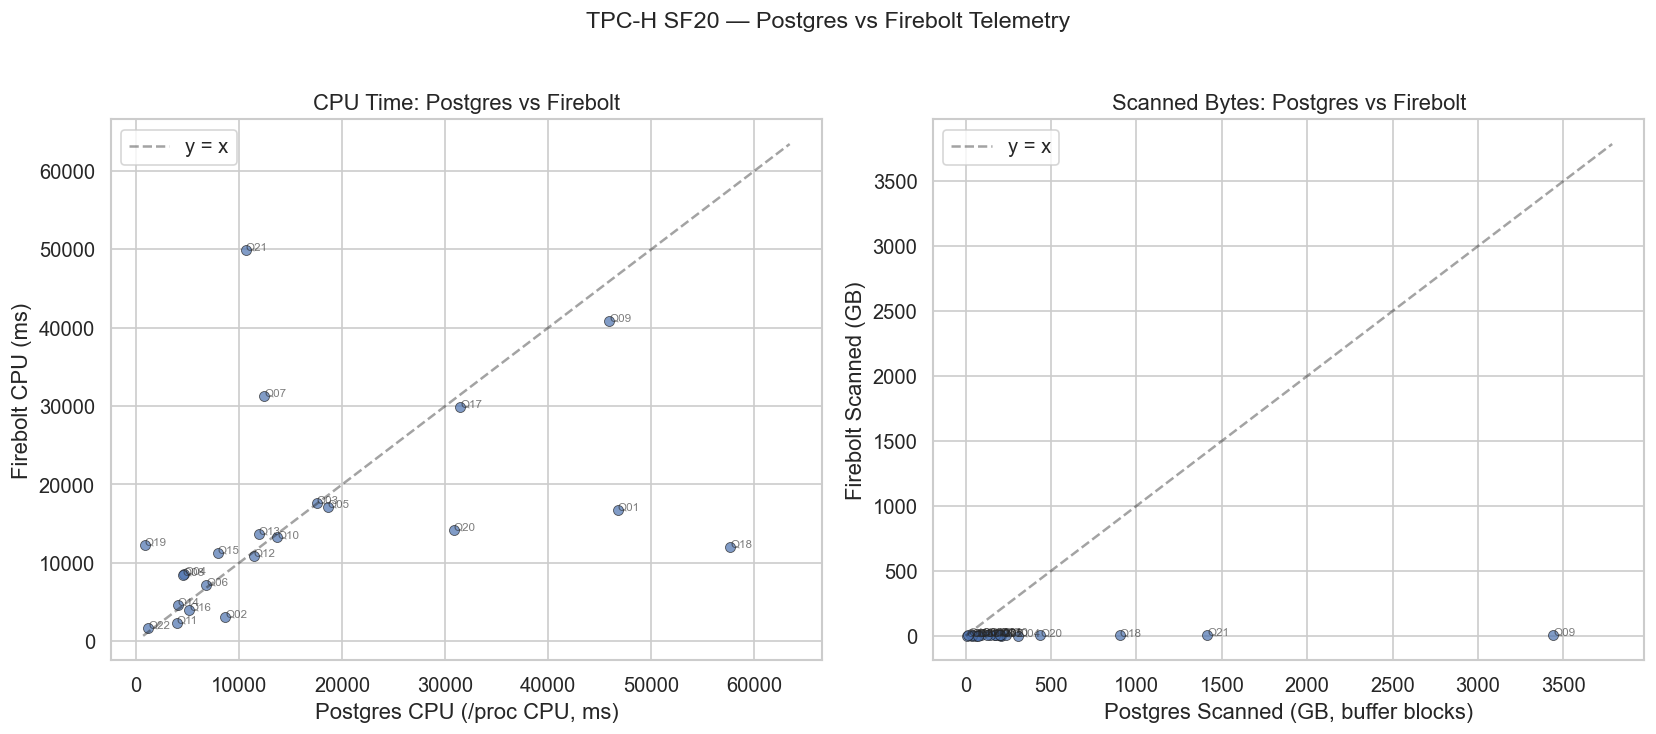

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CPU comparison
ax = axes[0]
ax.scatter(merged['pg_cpu_ms'], merged['fb_cpu_ms'],
           alpha=0.7, edgecolors='k', linewidths=0.5)
for _, r in merged.iterrows():
    ax.annotate(r['query_label'], (r['pg_cpu_ms'], r['fb_cpu_ms']),
                fontsize=7, alpha=0.6)
lo = min(merged['pg_cpu_ms'].min(), merged['fb_cpu_ms'].min()) * 0.8
hi = max(merged['pg_cpu_ms'].max(), merged['fb_cpu_ms'].max()) * 1.1
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='y = x')
ax.set_xlabel(f'Postgres CPU ({pg_cpu_label}, ms)')
ax.set_ylabel('Firebolt CPU (ms)')
ax.set_title('CPU Time: Postgres vs Firebolt')
ax.legend()

# Scan comparison
ax = axes[1]
ax.scatter(merged['scanned_bytes_mean'] / 1e9, merged['fb_scan_bytes'] / 1e9,
           alpha=0.7, edgecolors='k', linewidths=0.5)
for _, r in merged.iterrows():
    ax.annotate(r['query_label'],
                (r['scanned_bytes_mean'] / 1e9, r['fb_scan_bytes'] / 1e9),
                fontsize=7, alpha=0.6)
lo = min(merged['scanned_bytes_mean'].min(), merged['fb_scan_bytes'].min()) / 1e9 * 0.8
hi = max(merged['scanned_bytes_mean'].max(), merged['fb_scan_bytes'].max()) / 1e9 * 1.1
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='y = x')
ax.set_xlabel('Postgres Scanned (GB, buffer blocks)')
ax.set_ylabel('Firebolt Scanned (GB)')
ax.set_title('Scanned Bytes: Postgres vs Firebolt')
ax.legend()

fig.suptitle('TPC-H SF20 — Postgres vs Firebolt Telemetry', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 5. Rank correlation between backends

Even if absolute values differ, do the two backends agree on which
queries are expensive vs cheap?

In [7]:
rank_pairs = [
    ('pg_cpu_ms', 'fb_cpu_ms', 'CPU Time'),
    ('scanned_bytes_mean', 'fb_scan_bytes', 'Scanned Bytes'),
]

rank_rows = []
for pg_col, fb_col, label in rank_pairs:
    rho, p_rho = stats.spearmanr(merged[pg_col], merged[fb_col])
    tau, p_tau = stats.kendalltau(merged[pg_col], merged[fb_col])
    rank_rows.append({
        'metric': label,
        'spearman_rho': rho, 'spearman_p': p_rho,
        'kendall_tau': tau, 'kendall_p': p_tau,
    })

rank_df = pd.DataFrame(rank_rows)
display(rank_df.style.format({
    'spearman_rho': '{:.4f}', 'spearman_p': '{:.4f}',
    'kendall_tau': '{:.4f}', 'kendall_p': '{:.4f}',
}).background_gradient(subset=['spearman_rho'], cmap='RdYlGn', vmin=0, vmax=1))

,metric,spearman_rho,spearman_p,kendall_tau,kendall_p
0,CPU Time,0.7030,0.0003,0.5065,0.0007
1,Scanned Bytes,0.2434,0.2751,0.1602,0.3140


## 6. Postgres: /proc CPU vs EXPLAIN ANALYZE wall-clock

If `/proc` data is available, compare the two Postgres-side CPU estimates
to show why EXPLAIN ANALYZE time is not true CPU.

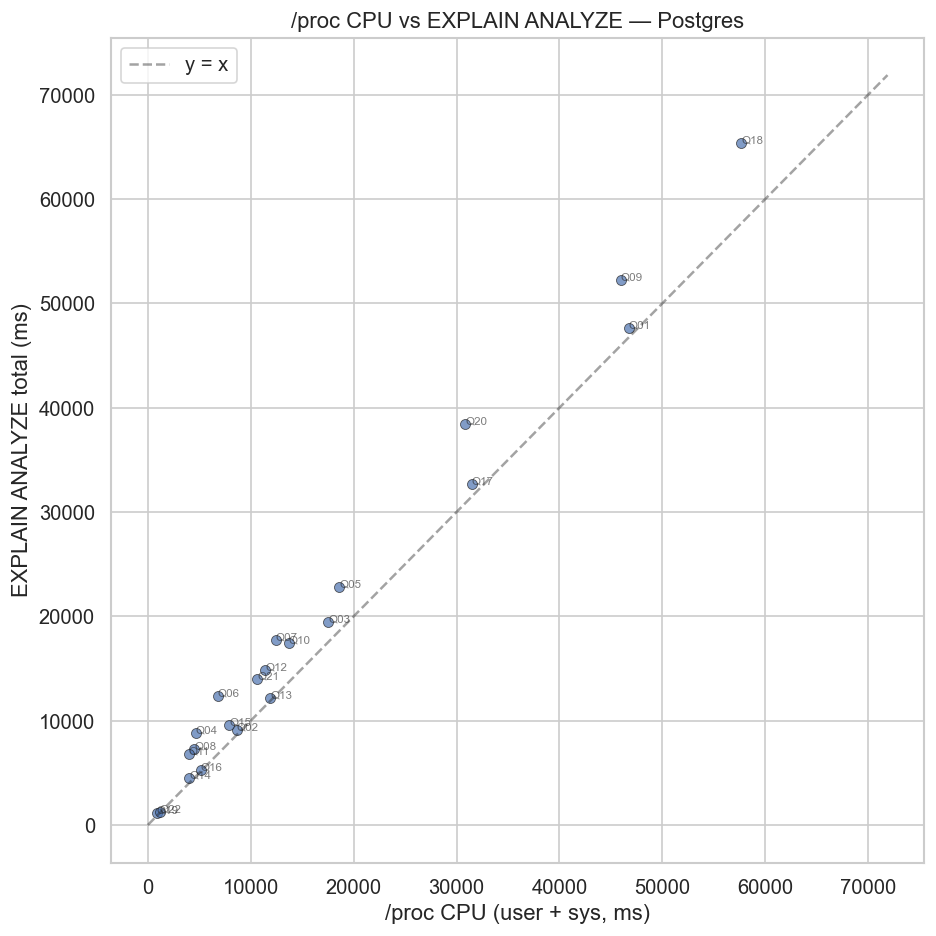

EXPLAIN / /proc ratio:
  Median: 1.22x
  Mean:   1.27x
  Max:    1.89x

A ratio > 1 means EXPLAIN ANALYZE includes I/O wait time
that is NOT actual CPU work.


In [8]:
if has_proc:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(merged['proc_cpu_ms_mean'], merged['explain_total_ms_mean'],
               alpha=0.7, edgecolors='k', linewidths=0.5)
    for _, r in merged.iterrows():
        ax.annotate(r['query_label'],
                    (r['proc_cpu_ms_mean'], r['explain_total_ms_mean']),
                    fontsize=7, alpha=0.6)
    lo = 0
    hi = max(merged['proc_cpu_ms_mean'].max(),
             merged['explain_total_ms_mean'].max()) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='y = x')
    ax.set_xlabel('/proc CPU (user + sys, ms)')
    ax.set_ylabel('EXPLAIN ANALYZE total (ms)')
    ax.set_title('/proc CPU vs EXPLAIN ANALYZE — Postgres')
    ax.legend()
    fig.tight_layout()
    plt.show()

    # Ratio
    merged['explain_over_proc'] = (
        merged['explain_total_ms_mean'] /
        merged['proc_cpu_ms_mean'].replace(0, np.nan)
    )
    print(f'EXPLAIN / /proc ratio:')
    print(f'  Median: {merged["explain_over_proc"].median():.2f}x')
    print(f'  Mean:   {merged["explain_over_proc"].mean():.2f}x')
    print(f'  Max:    {merged["explain_over_proc"].max():.2f}x')
    print('\nA ratio > 1 means EXPLAIN ANALYZE includes I/O wait time')
    print('that is NOT actual CPU work.')
else:
    print('/proc CPU data not available — skipping this comparison.')
    print('This is expected if PostgreSQL runs in Docker or on a remote host.')

## 7. Summary

In [9]:
print('CPU Ratio (Firebolt / Postgres) per query:')
print(f'  Median: {merged["cpu_ratio_fb_pg"].median():.2f}x')
print(f'  Mean:   {merged["cpu_ratio_fb_pg"].mean():.2f}x')
print(f'  Min:    {merged["cpu_ratio_fb_pg"].min():.2f}x')
print(f'  Max:    {merged["cpu_ratio_fb_pg"].max():.2f}x')

print(f'\nScan Ratio (Firebolt / Postgres) per query:')
print(f'  Median: {merged["scan_ratio_fb_pg"].median():.2f}x')
print(f'  Mean:   {merged["scan_ratio_fb_pg"].mean():.2f}x')

rho_cpu = stats.spearmanr(merged['pg_cpu_ms'], merged['fb_cpu_ms'])[0]
rho_scan = stats.spearmanr(merged['scanned_bytes_mean'], merged['fb_scan_bytes'])[0]
print(f'\nRank agreement (Spearman rho):')
print(f'  CPU:  {rho_cpu:.3f}')
print(f'  Scan: {rho_scan:.3f}')
print(f'\nPostgres CPU source: {pg_cpu_label}')

CPU Ratio (Firebolt / Postgres) per query:
  Median: 0.99x
  Mean:   1.81x
  Min:    0.21x
  Max:    14.29x

Scan Ratio (Firebolt / Postgres) per query:
  Median: 0.02x
  Mean:   0.04x

Rank agreement (Spearman rho):
  CPU:  0.703
  Scan: 0.243

Postgres CPU source: /proc CPU
